# Chapter 03 — Forward Rates and FRA Pricing

# 1. Background

## Forward Curves, No-Arbitrage, and FRA Valuation

This notebook introduces:

- implied forward rates
- forward curve construction
- no-arbitrage relationships
- FRA pricing
- forward curve interpretation
- interest rate expectations

We build a simplified forward rate framework using:

- zero curves
- discount factors
- implied forward rates

## Learning Objectives

After completing this notebook, you should understand:

1. What forward rates represent
2. How forward rates are implied from discount factors
3. Why forward curves matter in fixed income trading
4. How FRA contracts work
5. How FRA valuation depends on curve shape
6. Why forward curves are sensitive to interpolation


## FO Quant Perspective

Forward curves are among the most important objects in interest rate trading.

Traders continuously monitor:

- forward steepness
- policy expectations
- curve roll-down
- future funding expectations

Forward curves are fundamental for:

- swap pricing
- swaption pricing
- FRA valuation
- LIBOR Market Models (LMM)
- XVA simulations

---


# 2. Import Libraries

In [1]:
import sys
import os

project_root = os.path.abspath("../python")

sys.path.append(project_root)

import numpy as np
import matplotlib.pyplot as plt

from curve import YieldCurve
from market_data import load_market_curve
from forward_rates import generate_forward_curve
from fra import FRA
from plotting import (
    plot_zero_curve,
    plot_forward_curve
)

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# 3. Forward Rate Theory

# What is a Forward Rate?

A forward rate represents:

> the market-implied future interest rate between two future dates.

Unlike spot rates, forward rates are not directly observed.

They are implied from discount factors.



## No-Arbitrage Principle

Forward rates are derived using no-arbitrage relationships.

If discount factors are known:

$$ DF(t) = e^{-r(t)t} $$

then the implied forward rate between \(t_1\) and \(t_2\) is:

$$
F(t_1,t_2) = \frac{DF(t_1)}{DF(t_2)} - 1
$$

divided by the accrual period:

$$
F(t_1,t_2) = \frac{\frac{DF(t_1)}{DF(t_2)} - 1}{t_2 - t_1}
$$


## Financial Interpretation

Forward rates encode expectations about:

- future central bank policy
- inflation expectations
- future liquidity conditions
- macroeconomic outlook
- 
---

# 4. Loading Market Zero Curve

We now load a simplified USD zero curve.

In production systems, curves are bootstrapped from:

- OIS swaps
- IRS swaps
- futures
- treasury instruments

For educational purposes, we use simplified zero rates.


In [4]:
maturities, rates = load_market_curve(
    "../data/usd_zero_curve.csv"
)

curve = YieldCurve(
    maturities,
    rates
)

print("Maturities:")
print(maturities)

print("\nZero Rates:")
print(rates)

Maturities:
[ 0.25  0.5   1.    2.    3.    5.    7.   10.   15.   20.   30.  ]

Zero Rates:
[0.02   0.021  0.022  0.024  0.025  0.027  0.0285 0.03   0.032  0.033
 0.034 ]


---
# 5. Plot Market Zero Curve

The zero curve represents:

> continuously compounded spot rates.

The shape of the curve is extremely important because it affects:

- discounting
- pricing
- forward rates
- risk sensitivities

Typical shapes include:

- upward sloping
- inverted
- humped


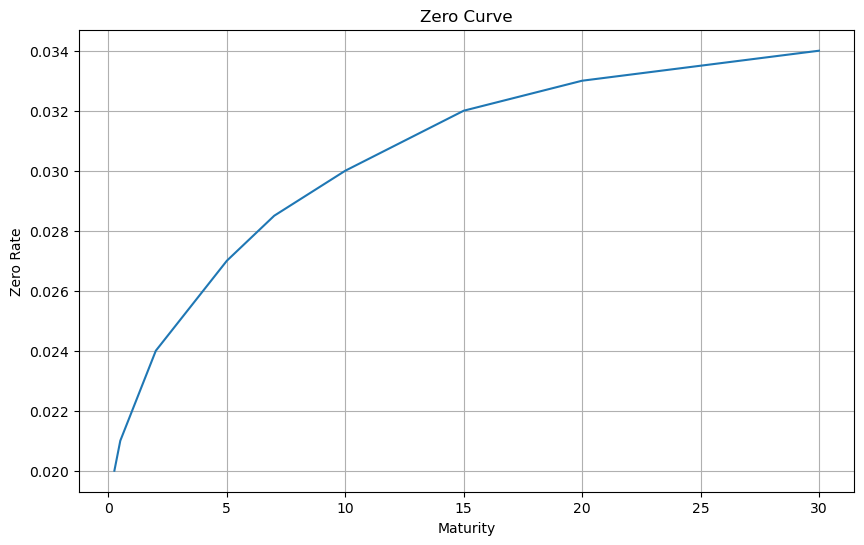

In [5]:
plot_zero_curve(
    maturities,
    rates
)

---
# 6. Discount Factors

Discount factors are computed using:

$$ DF(t) = e^{-r(t)t} $$

They represent:

> the present value of receiving 1 unit of currency at future time \(t\).

Discount factors are fundamental in all fixed income pricing systems.

In [6]:
test_maturities = [1, 2, 5, 10, 20, 30]

for t in test_maturities:

    df = curve.discount_factor(t)

    print(
        f"Maturity = {t:2d}Y | "
        f"Discount Factor = {df:.6f}"
    )

Maturity =  1Y | Discount Factor = 0.978240
Maturity =  2Y | Discount Factor = 0.953134
Maturity =  5Y | Discount Factor = 0.873716
Maturity = 10Y | Discount Factor = 0.740818
Maturity = 20Y | Discount Factor = 0.516851
Maturity = 30Y | Discount Factor = 0.360595


---
# 7. Forward Curve Construction

We now compute the implied forward curve.

The forward curve represents:

> market-implied future short-term interest rates.

Forward curves are significantly more sensitive than zero curves.

Small interpolation errors may create:

- unstable forwards
- oscillations
- unrealistic pricing

This is why curve smoothness is critically important.


In [16]:
times, fwds = generate_forward_curve(
    curve,
    start=0.25,
    end=29.5,
    step=0.5
)

print("Forward curve generated successfully.")


Forward curve generated successfully.


## Forward Curve Visualization

Forward curves often contain much more information than zero curves.

Traders analyze forward curves to understand:

- future rate expectations
- expected central bank actions
- market stress
- inflation expectations

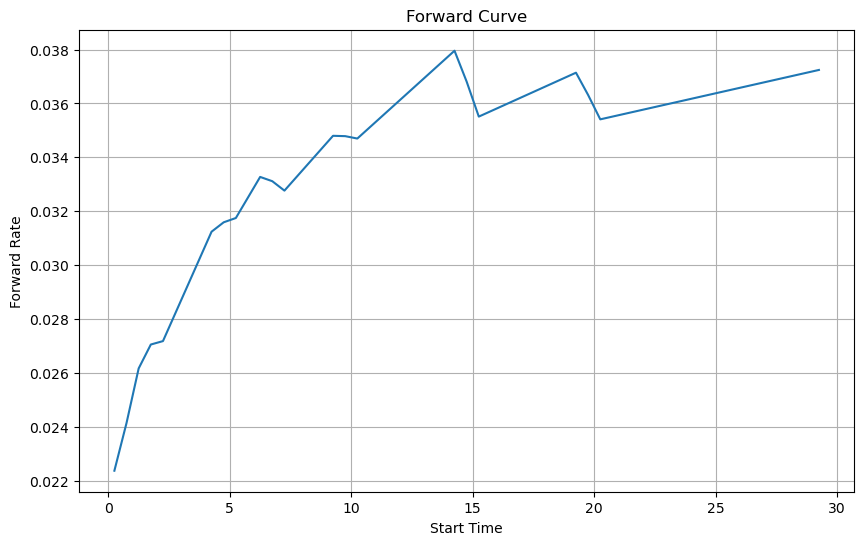

In [17]:
plot_forward_curve(
    times,
    fwds
)


---
# 8. Forward Rate Agreements (FRA)

An FRA allows counterparties to lock a future borrowing/lending rate.

Typical notation:

- 3x6 FRA
- 6x9 FRA

Example:

3x6 FRA means:

- loan starts in 3 months
- loan ends in 6 months


## FRA Payoff

The FRA payoff is:

$$
N(F-K)\Delta
$$

where:

| Symbol | Meaning |
|---|---|
| \(N\) | Notional |
| \(F\) | Implied forward |
| \(K\) | FRA strike |
| \(\Delta\) | Accrual fraction |

Present value:

$$
PV =
N(F-K)\Delta DF
$$


## FRA Trading Usage

FRAs are used for:

- funding hedging
- policy speculation
- short-end curve trading



## 8.1 Create FRA Instrument

In [28]:
fra = FRA(
    notional=10_000_000,
    strike=0.025,
    start=1.0,
    end=1.5
)

print("FRA instrument created.")

FRA instrument created.


## 8.2 Compute Implied Forward Rate

In [29]:
fwd = fra.implied_forward_rate(curve)

print(
    f"Implied Forward Rate = {fwd:.4%}"
)


Implied Forward Rate = 2.5157%


## 8.3 FRA Valuation

The FRA value depends on:

- implied forward rate
- FRA strike
- discount factor
- accrual period

If:

$$
F > K
$$

then the FRA has positive value for the fixed-rate payer.


In [31]:
pv = fra.value(curve)

print(
    f"FRA Present Value = ${pv:,.2f}"
)

FRA Present Value = $757.91


---
# 9. FRA Sensitivity to Curve Shifts

Forward instruments are highly sensitive to curve movements.

We now shock the curve upward by +10bp.

This simulates:

- monetary tightening
- higher inflation expectations
- liquidity stress


## 9.1 Create Shocked Curve

In [35]:
shocked_rates = rates + 0.001

shocked_curve = YieldCurve(
    maturities,
    shocked_rates
)

## 9.2 Compare Forward Curves

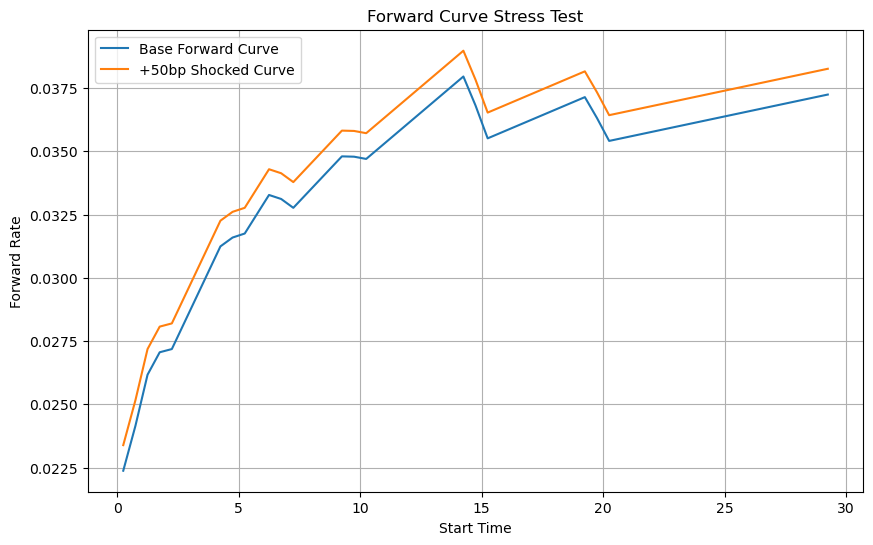

In [36]:
times2, fwds2 = generate_forward_curve(
    shocked_curve,
    start=0.25,
    end=29.5,
    step=0.5
)

plt.figure()

plt.plot(
    times,
    fwds,
    label="Base Forward Curve"
)

plt.plot(
    times2,
    fwds2,
    label="+50bp Shocked Curve"
)

plt.title("Forward Curve Stress Test")

plt.xlabel("Start Time")
plt.ylabel("Forward Rate")

plt.legend()

plt.grid()

plt.show()

## 9.3 FRA Revaluation

In [37]:
pv_shocked = fra.value(
    shocked_curve
)

print(
    f"Base FRA PV    = ${pv:,.2f}"
)

print(
    f"Shocked FRA PV = ${pv_shocked:,.2f}"
)

print(
    f"PV Change      = ${pv_shocked-pv:,.2f}"
)

Base FRA PV    = $757.91
Shocked FRA PV = $5,641.87
PV Change      = $4,883.96


---
# 11. Summary

In this notebook we implemented:

- zero curves
- discount factors
- implied forward rates
- forward curve construction
- FRA valuation
- curve stress testing


## 11.1 Key Quantitative Finance Concepts

This chapter introduced:

- no-arbitrage pricing
- implied rates
- forward discounting
- FRA valuation
- curve sensitivity



## 11.2 Important Trading Insight

The FRA sensitivity demonstrates how forward products react to:

- monetary policy expectations
- central bank decisions
- inflation shocks


Forward products are much more sensitive than spot products.

Small curve shifts can create:

- large PnL swings
- hedge instability
- funding risk changes


## 11.3 Why This Matters

Forward curves are foundational for:

- swap pricing
- swaption pricing
- SABR calibration
- LIBOR Market Models
- interest rate Monte Carlo simulation
